In [252]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  

# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd  


# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  

# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  

# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  


# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  

# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  

# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  

# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  

# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  


# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  

# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  

# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  

# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  


# Offers utilities for generating random numbers and sequences.
import random  

# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

In [253]:
import pandas as pd

def synchronize_adult_columns(data, column1='isAdult', column2='Adult'):
    """
    Confronta due colonne in un DataFrame e imposta entrambe a 1 
    se i valori sono diversi.

    Args:
        data (pd.DataFrame): Il DataFrame contenente le colonne da confrontare.
        column1 (str): Nome della prima colonna. Default 'isAdult'.
        column2 (str): Nome della seconda colonna. Default 'adult'.

    Returns:
        pd.DataFrame: Il DataFrame aggiornato.
    """
    # Assicurati che le colonne siano del tipo intero
    data[column1] = data[column1].astype(int)
    data[column2] = data[column2].astype(int)

    # Aggiorna entrambe le colonne a 1 se i valori sono diversi
    data.loc[data[column1] != data[column2], [column1, column2]] = 1

    return data


### Loading datasets

The code snippet loads `data_train` and `data_test` from: 


In [254]:
train_path = "data/output/01_data_understanding/data_train.csv"
test_path = "data/output/01_data_understanding/data_test.csv"
data_train = pd.read_csv(train_path)
data_test = pd.read_csv(test_path)

print("Datasets loaded successfully.")        # Prints a message if the datasets are loaded successfully.

Datasets loaded successfully.


In [255]:
synchronize_adult_columns(data_train)
synchronize_adult_columns(data_test)

# drop isAdult column
data_train.drop(columns=['isAdult'], inplace=True)
data_test.drop(columns=['isAdult'], inplace=True)

### Outliers

In [256]:
from scipy.stats import kurtosis, skew

# Initialize an empty dictionary to store the results
results = {'Variable': [], 'Excess Kurtosis': [], 'Skewness': []}

for f in data_train.select_dtypes(include=['int']):
    # Append the results to the dictionary
    results['Variable'].append(f)
    results['Excess Kurtosis'].append(kurtosis(data_train[f]))
    results['Skewness'].append(skew(data_train[f]))

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Print the DataFrame
print(results_df)

            Variable  Excess Kurtosis   Skewness
0             rating         0.636524  -0.619030
1          startYear         0.989336  -1.113975
2           numVotes       954.729331  27.930432
3        totalImages      1047.874872  28.464521
4        totalVideos      3438.446296  49.823770
..               ...              ...        ...
193              War        73.331341   8.679363
194          Western        47.492761   7.035109
195          unknown        41.734042   6.613172
196       totalMedia      1022.606375  28.036409
197  startYearDecade         0.961709  -1.067195

[198 rows x 3 columns]


In [257]:
def detect_outliers(data, columns_to_check, threshold_std_dev=2.0, threshold_iqr=1.5):
    """
    Identifies potential outliers in the specified columns of a DataFrame using two methods:
    1. Standard deviation.
    2. Interquartile range (IQR).

    Args:
        data (pd.DataFrame): The input DataFrame.
        columns_to_check (list): List of column names to check for outliers.
        threshold_std_dev (float): Multiplier for standard deviation threshold.
        threshold_iqr (float): Multiplier for IQR threshold.

    Returns:
        dict: A dictionary with the following keys:
            - "columns_with_outliers_std_dev": Columns with outliers detected by standard deviation.
            - "columns_with_outliers_iqr": Columns with outliers detected by IQR.
            - "common_outlier_columns": Columns with outliers detected by both methods.
    """
    # Select only the specified columns
    numeric_columns = data[columns_to_check]

    # Calculate quartiles and IQR
    quartiles = numeric_columns.quantile([0.25, 0.75])
    lower_quartile = quartiles.loc[0.25]
    upper_quartile = quartiles.loc[0.75]
    interquartile_range = upper_quartile - lower_quartile

    # Identify outliers using the standard deviation method
    outliers_std_dev = (numeric_columns - numeric_columns.mean()).abs() > threshold_std_dev * numeric_columns.std()

    # Identify outliers using the IQR method
    outliers_iqr = (numeric_columns < lower_quartile - threshold_iqr * interquartile_range) | \
                   (numeric_columns > upper_quartile + threshold_iqr * interquartile_range)

    # Determine columns with outliers for each method
    columns_with_outliers_std_dev = numeric_columns.columns[outliers_std_dev.any()]
    columns_with_outliers_iqr = numeric_columns.columns[outliers_iqr.any()]

    # Find common columns with outliers detected by both methods
    common_outlier_columns = columns_with_outliers_std_dev.intersection(columns_with_outliers_iqr)

    return {
        "columns_with_outliers_std_dev": columns_with_outliers_std_dev.tolist(),
        "columns_with_outliers_iqr": columns_with_outliers_iqr.tolist(),
        "common_outlier_columns": common_outlier_columns.tolist()
    }

# Example usage:
columns_to_check = [
    "runtimeMinutes", 
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "totalRecognitions", 
    "NumberOfGenres"
]

outliers_info = detect_outliers(data_train, columns_to_check)
print("\nColumns with potential outliers detected by standard deviation:")
print(outliers_info["columns_with_outliers_std_dev"])
print("\nColumns with potential outliers detected by IQR:")
print(outliers_info["columns_with_outliers_iqr"])
print("\nColumns with potential outliers detected by both methods:")
print(outliers_info["common_outlier_columns"])



Columns with potential outliers detected by standard deviation:
['runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'totalRecognitions']

Columns with potential outliers detected by IQR:
['runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'totalRecognitions']

Columns with potential outliers detected by both methods:
['runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'totalRecognitions']


# Correlation
Let's analyze the correlations between columns.

In [258]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def analyze_correlation(data, columns, show_plot=True, top_n=10):
    """
    Analyze the correlation matrix for a subset of columns, optionally visualize a heatmap, 
    and return the top-N and bottom-N correlation pairs.
    
    Args:
        data (pd.DataFrame): The input DataFrame.
        columns (list): List of column names to include in the correlation analysis.
        show_plot (bool): Whether to display the heatmap. Default is True.
        top_n (int): Number of top and bottom correlation pairs to return. Default is 10.
    
    Returns:
        tuple: Two DataFrames containing the top-N and bottom-N correlation pairs.
    """
    # Filter the DataFrame to include only the desired subset of columns
    subset_data = data[columns]
    
    # Compute the correlation matrix for the subset
    corr_matrix = subset_data.corr()

    if show_plot:
        # Create a mask for the upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

        # Create a custom diverging palette
        cmap = 'RdYlBu'

        # Plot the heatmap
        plt.figure(figsize=(8, 4))
        sns.heatmap(corr_matrix, mask=mask, center=0, annot=True, fmt='.2f', square=True, cmap=cmap)
        plt.title("Correlation Heatmap")
        plt.show()

    # Flatten the correlation matrix and reset the index to get all pairs
    corr_pairs = corr_matrix.abs().unstack().reset_index()

    # Rename the columns for better understanding
    corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

    # Remove self-correlations (correlation of a variable with itself)
    corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]

    # Sort by correlation value in descending order
    sorted_corr_pairs = corr_pairs.sort_values(by='Correlation', ascending=True)

    # Drop duplicate pairs (e.g., A-B and B-A)
    sorted_corr_pairs = sorted_corr_pairs.drop_duplicates(subset=['Correlation'])

    # Get the top-N and bottom-N correlation pairs
    top_corr_pairs = sorted_corr_pairs.head(top_n)
    bottom_corr_pairs = sorted_corr_pairs.tail(top_n)

    return top_corr_pairs, bottom_corr_pairs

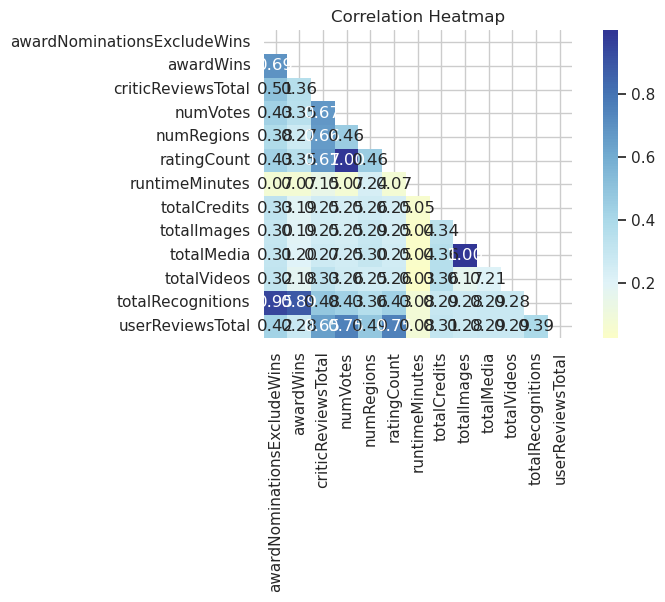

(                      Variable 1         Variable 2  Correlation
 136                  totalVideos     runtimeMinutes     0.025876
 86                runtimeMinutes        totalImages     0.037714
 123                   totalMedia     runtimeMinutes     0.038581
 85                runtimeMinutes       totalCredits     0.053290
 45                      numVotes     runtimeMinutes     0.074055
 83                runtimeMinutes        ratingCount     0.074056
 79                runtimeMinutes          awardWins     0.074261
 6    awardNominationsExcludeWins     runtimeMinutes     0.074269
 89                runtimeMinutes  totalRecognitions     0.080144
 162             userReviewsTotal     runtimeMinutes     0.080166,
                       Variable 1                   Variable 2  Correlation
 30            criticReviewsTotal                   numRegions     0.662410
 41                      numVotes           criticReviewsTotal     0.673692
 67                   ratingCount           c

In [259]:
# Specify the subset of columns for which you want the correlation matrix
subset_columns = [
    "awardNominationsExcludeWins", 
    "awardWins", 
    "criticReviewsTotal", 
    "numVotes", 
    "numRegions", 
    "ratingCount",
    "runtimeMinutes", 
    "totalCredits", 
    "totalImages", 
    "totalMedia",
    "totalVideos",
    "totalRecognitions",
    "userReviewsTotal"
]
analyze_correlation(data_train, subset_columns)


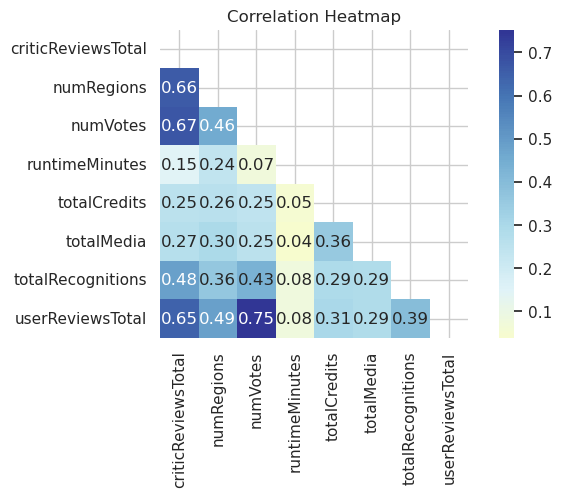

In [260]:
data_train = data_train.drop(columns='ratingCount')
data_test = data_test.drop(columns='ratingCount')

data_train = data_train.drop(columns='totalImages')
data_test = data_test.drop(columns='totalImages')

data_train = data_train.drop(columns='totalVideos')
data_test = data_test.drop(columns='totalVideos')

data_train = data_train.drop(columns='awardNominationsExcludeWins')
data_test = data_test.drop(columns='awardNominationsExcludeWins')

data_train = data_train.drop(columns='awardWins')
data_test = data_test.drop(columns='awardWins')

subset_columns = [
    "criticReviewsTotal",
    "numRegions", 
    "numVotes", 
    "runtimeMinutes",
    "totalCredits", 
    "totalMedia",
    "totalRecognitions", 
    "userReviewsTotal"
]


top_corr_pairs, bottom_corr_pairs = analyze_correlation(data_train, subset_columns)


# Standardization
First of all we plot the distribution of all numerical columns

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis

def plot_column_distribution(dataframe, column_name, bins=30):
    """
    Plots the distribution of a specific column in a dataset, 
    along with log-transformed and square root-transformed distributions.

    Args:
        dataframe (pd.DataFrame): The dataset containing the column.
        column_name (str): The name of the column to plot.
        bins (int): Number of bins for the histogram (default 30).
    """
    if column_name not in dataframe.columns:
        raise ValueError(f"The column '{column_name}' does not exist in the dataset.")

    # Validate the data
    column_data = dataframe[column_name].dropna()

    # Compute skewness and kurtosis for each transformation
    original_skewness = skew(column_data)
    original_kurtosis = kurtosis(column_data)  # Excess kurtosis (subtracts 3 automatically)

    log_transformed = np.log1p(column_data)
    log_skewness = skew(log_transformed)
    log_kurtosis = kurtosis(log_transformed)

    sqrt_transformed = np.sqrt(column_data)
    sqrt_skewness = skew(sqrt_transformed)
    sqrt_kurtosis = kurtosis(sqrt_transformed)

    # Set seaborn theme and colors
    sns.set_theme(style="whitegrid")

    colors = sns.color_palette("viridis")
    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    # Original distribution
    sns.histplot(column_data, bins=bins, kde=True, color=colors[0], alpha=0.6, ax=axes[0])
    axes[0].set_title(f'Original: {column_name}\n(Skewness: {original_skewness:.2f}, Kurtosis: {original_kurtosis:.2f})', fontsize=14)
    axes[0].set_xlabel(column_name, fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].spines['left'].set_visible(True)
    axes[0].spines['left'].set_linewidth(1.5)
    axes[0].spines['bottom'].set_linewidth(1.5)

    # Log-transformed distribution
    sns.histplot(log_transformed, bins=bins, kde=True, color=colors[3], alpha=0.6, ax=axes[1])
    axes[1].set_title(f'Log-Transformed: log({column_name} + 1)\n(Skewness: {log_skewness:.2f}, Kurtosis: {log_kurtosis:.2f})', fontsize=14)
    axes[1].set_xlabel(f'log({column_name} + 1)', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].spines['left'].set_visible(True)
    axes[1].spines['left'].set_linewidth(1.5)
    axes[1].spines['bottom'].set_linewidth(1.5)

    # Square root-transformed distribution
    sns.histplot(sqrt_transformed, bins=bins, kde=True, color=colors[5], alpha=0.6, ax=axes[2])
    axes[2].set_title(f'Square Root: sqrt({column_name})\n(Skewness: {sqrt_skewness:.2f}, Kurtosis: {sqrt_kurtosis:.2f})', fontsize=14)
    axes[2].set_xlabel(f'sqrt({column_name})', fontsize=12)
    axes[2].set_ylabel('Frequency', fontsize=12)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)
    axes[2].spines['left'].set_visible(True)
    axes[2].spines['left'].set_linewidth(1.5)
    axes[2].spines['bottom'].set_linewidth(1.5)

    # Adjust layout
    plt.tight_layout()
    plt.show()


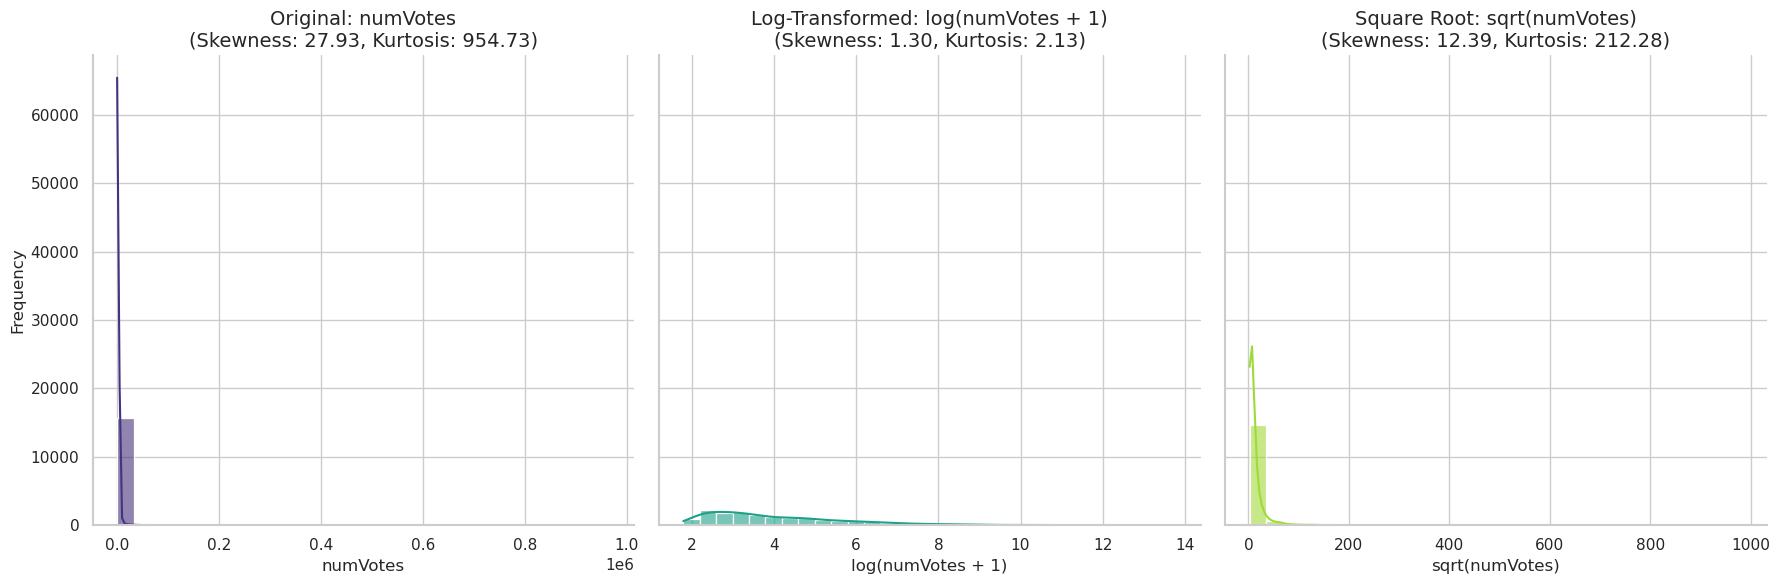

In [262]:
plot_column_distribution(data_train, 'numVotes')

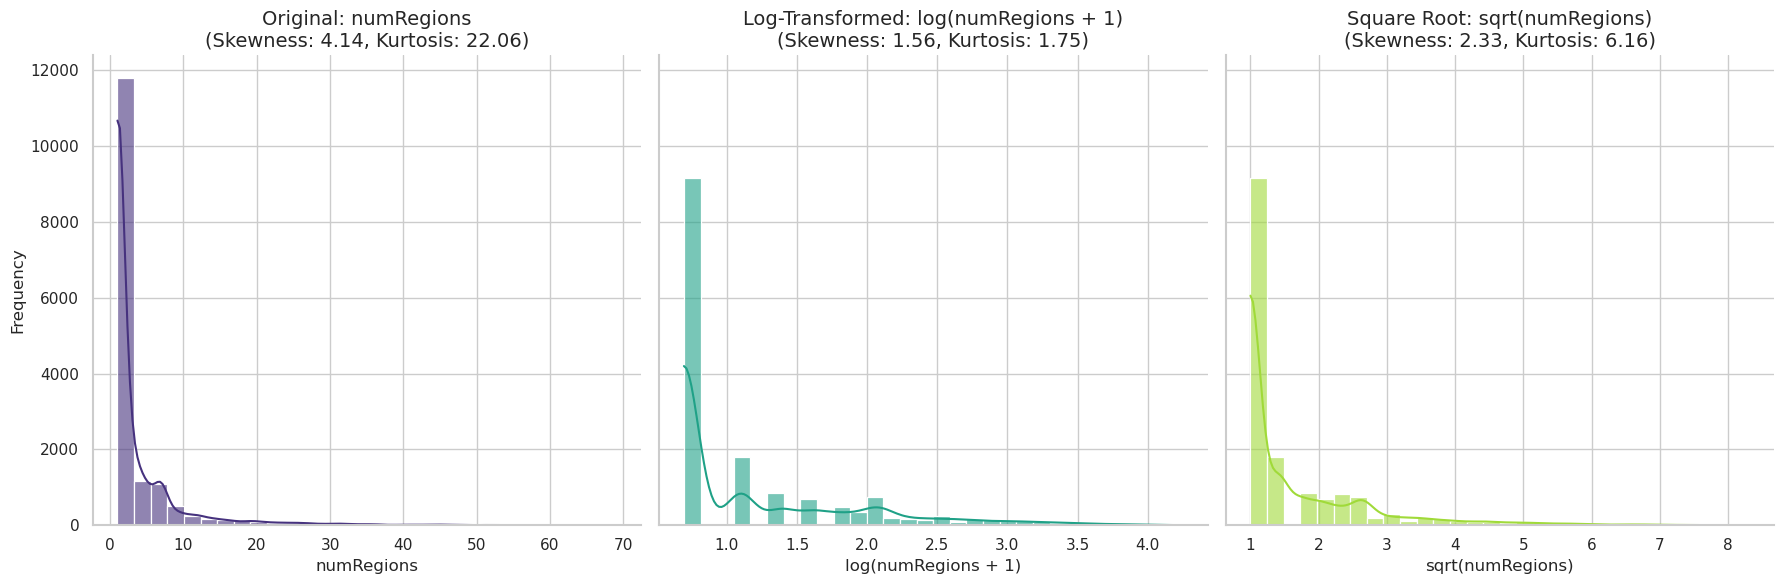

In [263]:
plot_column_distribution(data_train, 'numRegions')

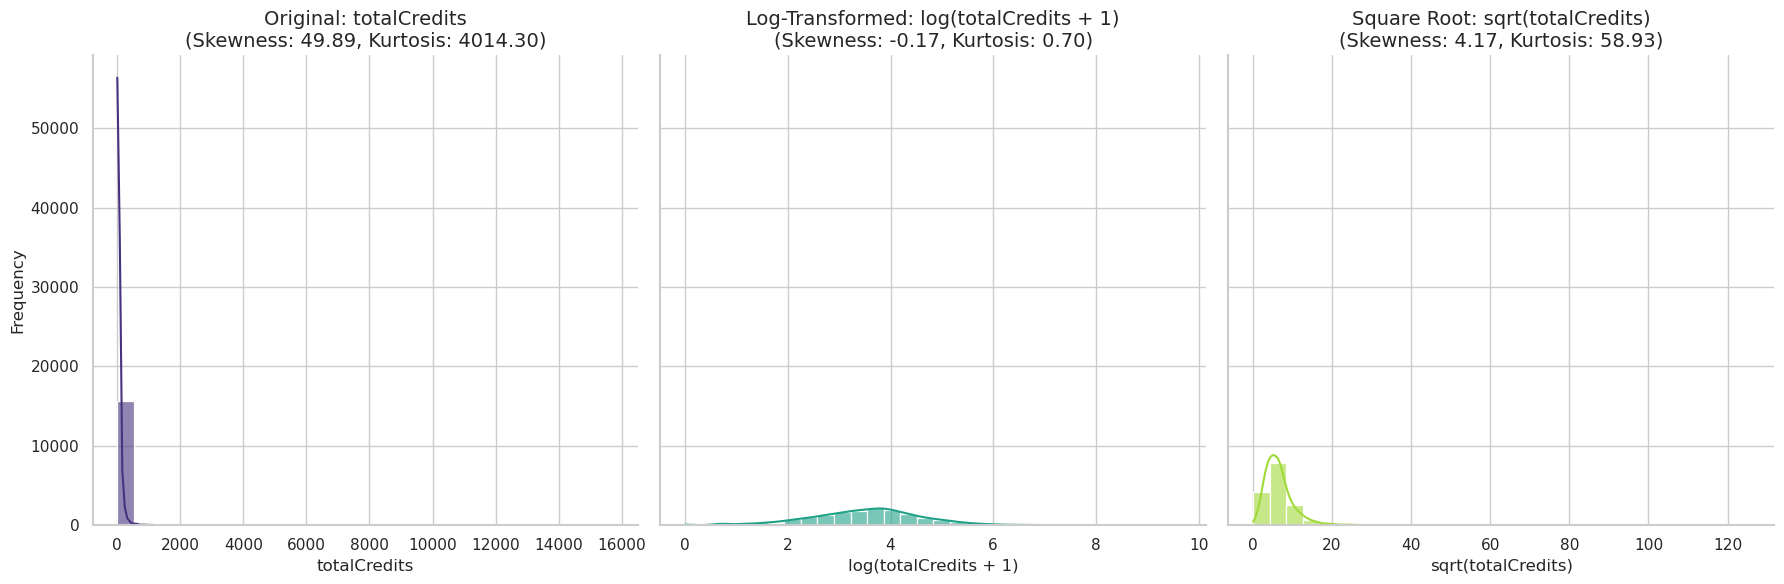

In [264]:
plot_column_distribution(data_train, 'totalCredits')

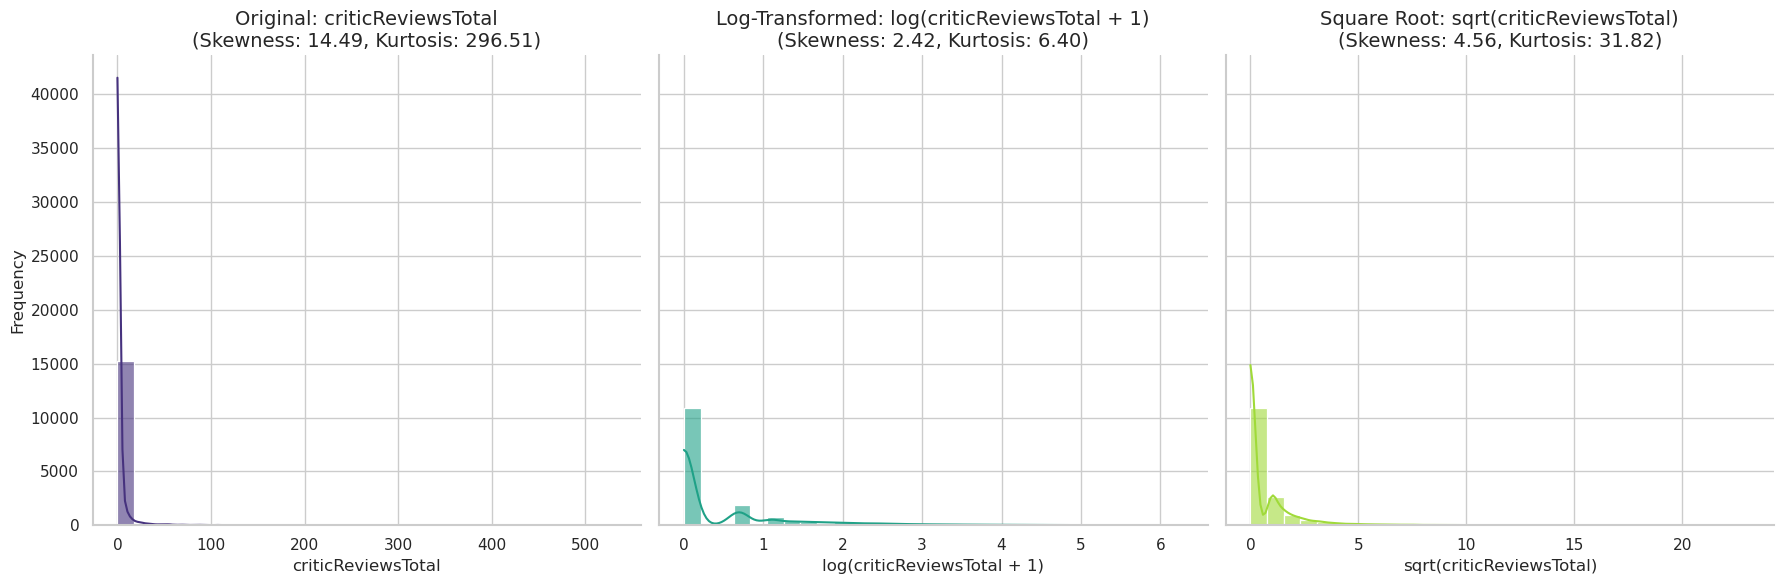

In [265]:
plot_column_distribution(data_train, 'criticReviewsTotal')

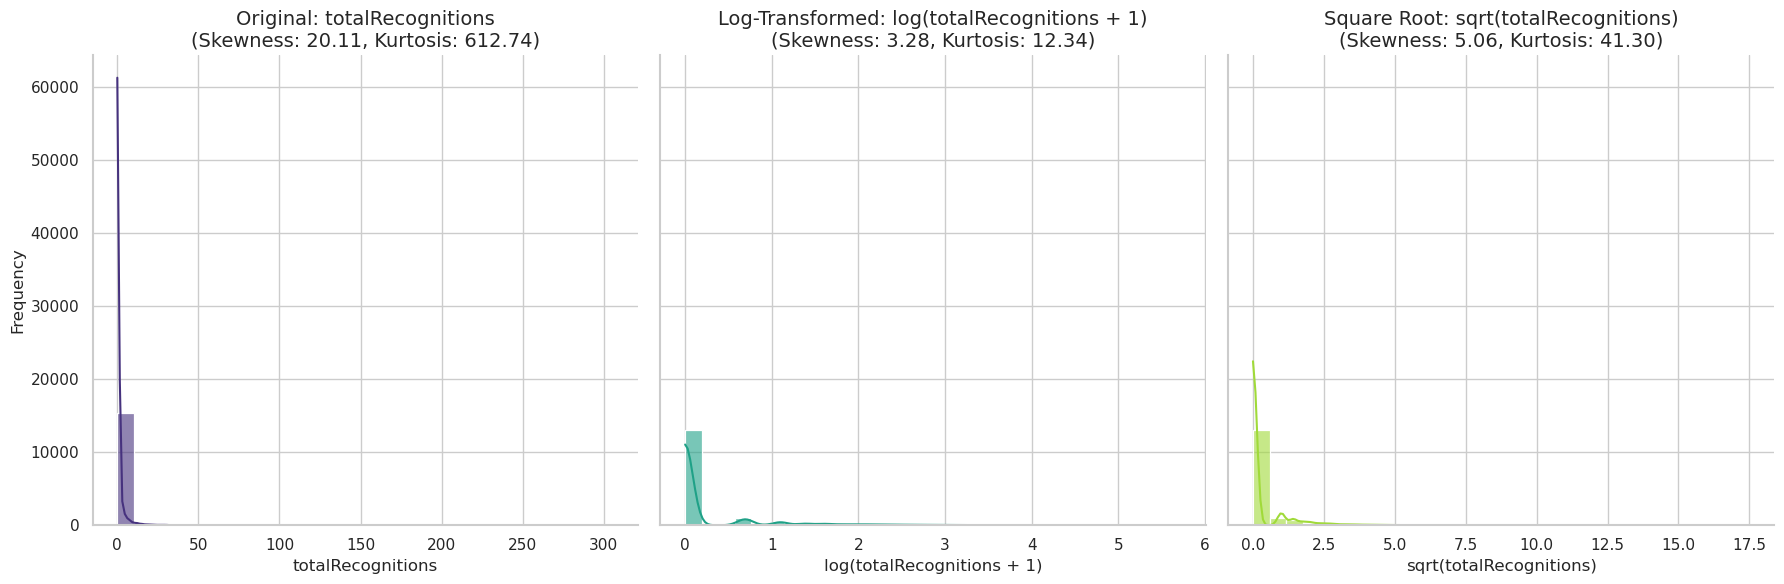

In [266]:
plot_column_distribution(data_train, 'totalRecognitions')

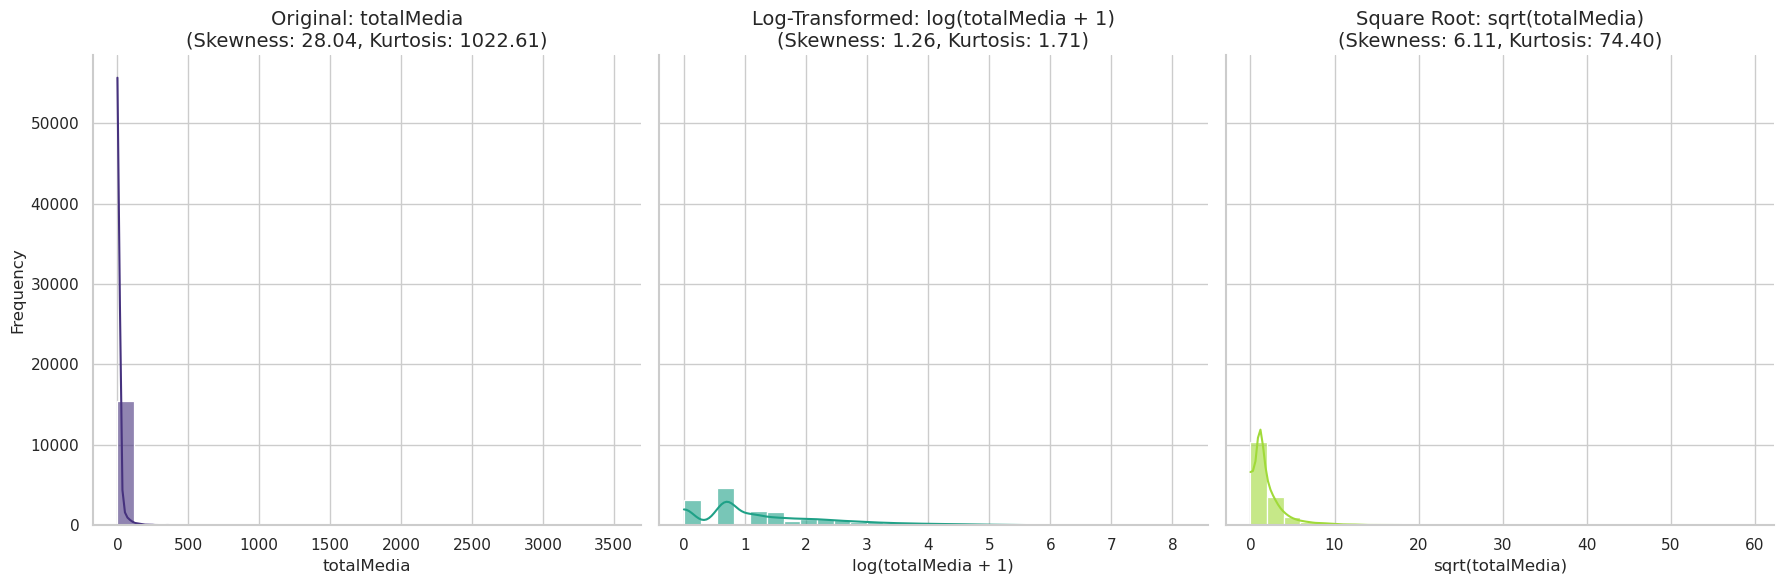

In [267]:
plot_column_distribution(data_train, 'totalMedia')

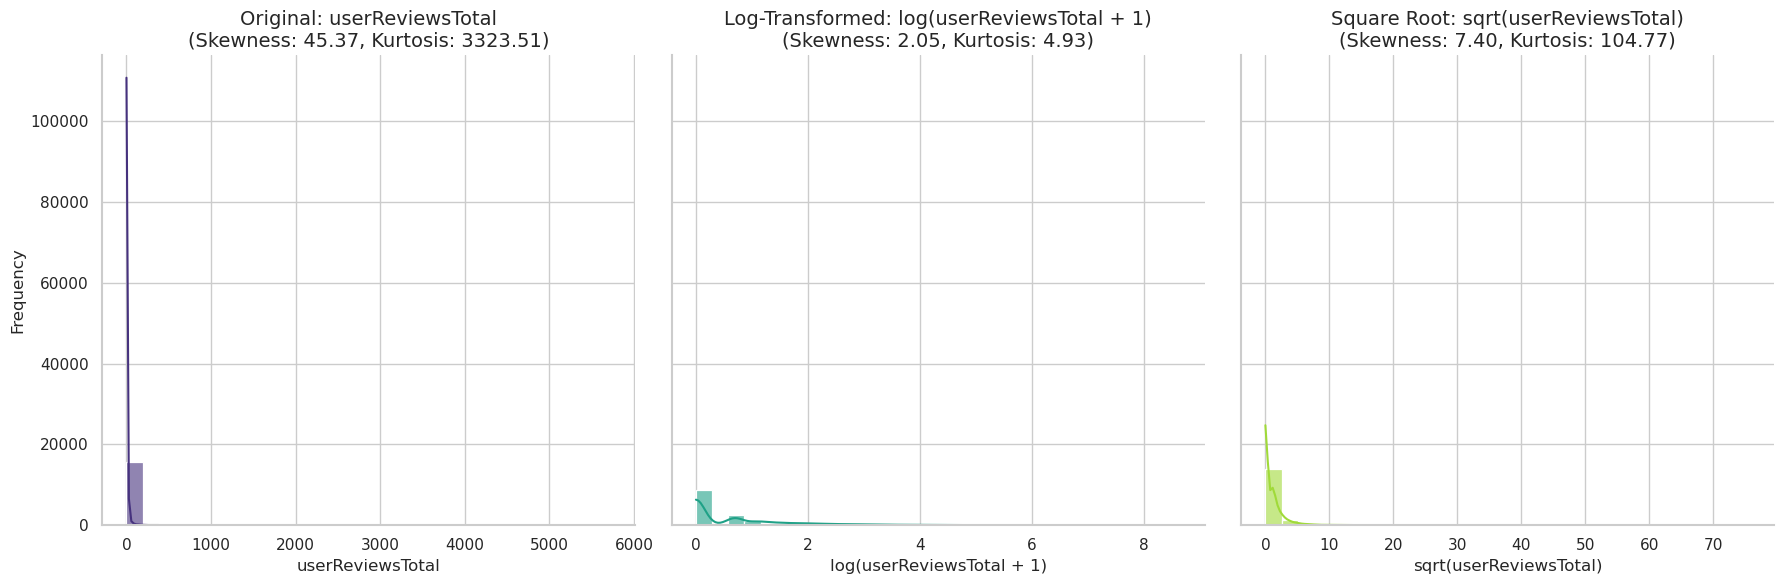

In [268]:
plot_column_distribution(data_train, 'userReviewsTotal')

# Distribution analysis
- `rating` perfect
- `runtimeMinutes`: **sqrt** sembra lasciare degli outlier e la skewness ottima con l'individuazione degli outlier porterà a un miglioramento della kurtosis
- `startYear`: non cambia con nessuna scala, invariato
- `numVotes` **log** strongly improves skewness and kurtosis
- `numRegions`: **log** migliora skewness e kurtosis
- `totalCredits`: **log** la rende una guassiana quasi perfetta
- `criticReviewsTotal`: **log**favorisce l'identificazione di outlier
- `NumberOfCountryOfOrigin`: invariato
- `nominations`: **log** migliora entrambi gliindicatori
- `numberOfGenres`: invariato
- `totalMedia`: **log**


Per runTimeMinutes e totalCredits eliminare code destra e sinistra

Non si tocca `rating`, `startYear`, `numberOfGenres`, `NumberOfCountryOfOrigin`.

Per `numVotes`, `numRegions`, `criticReviewsTotal`, `nominations` e `totalMedia` si elimina la coda a destra eliminando gli zeri.

Terminare con min-max scaling [0-10] per allinearsi a rating


In [269]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def transform_data(df):
    """
    Trasforma le colonne di un DataFrame secondo le regole definite.

    Args:
        df (pd.DataFrame): Il dataset originale.

    Returns:
        pd.DataFrame: Il dataset trasformato.
    """
    # Copia il DataFrame per evitare modifiche non volute
    transformed_df = df.copy()

    # Definizione delle trasformazioni
    transformations = {
        'runtimeMinutes': 'hrs',
        'numVotes': 'log',       
        'numRegions': 'log',     
        'totalCredits': 'log',    # Logaritmo
        'criticReviewsTotal': 'log',  # Logaritmo
        'totalRecognitions': 'log',  # Logaritmo
        'totalMedia': 'log',  # Logaritmo
        'awardWins': 'log',  # Logaritmo
        'userReviewsTotal': 'log'  # Logaritmo
    }

    for column, transformation in transformations.items():
        if column in transformed_df.columns:
            # Gestione delle trasformazioni
            if transformation == 'log':
                transformed_df[column] = np.log1p(transformed_df[column])  # log(x+1)
            elif transformation == 'sqrt':
                transformed_df[column] = np.sqrt(transformed_df[column])
            elif transformation == 'hrs':
                transformed_df[column] = transformed_df[column] / 60
    return transformed_df

# Applica le trasformazioni al dataset di addestramento
scaled_train = transform_data(data_train)
# Applica le trasformazioni al dataset di test
scaled_test = transform_data(data_test)


In [270]:
def summarize_columns(dataframe, columns):
    """
    Prints the minimum, maximum, median, and average of the specified columns in the DataFrame.

    Parameters:
    dataframe (pd.DataFrame): The DataFrame containing the data.
    columns (list): List of column names to summarize.

    Returns:
    None
    """
    summary = []
    for column in columns:
        if column in dataframe.columns:
            col_data = dataframe[column]
            if pd.api.types.is_numeric_dtype(col_data):
                summary.append({
                    "Column": column,
                    "Min": col_data.min(),
                    "Max": col_data.max(),
                    "Median": col_data.median(),
                    "avg": col_data.mean(),
                    "Std Dev": col_data.std()
                })
            else:
                print(f"Skipping non-numeric column: {column}")
        else:
            print(f"Column '{column}' not found in the DataFrame.")
    print(pd.DataFrame(summary))

In [271]:
columns_to_scale = [
    "rating",
    "runtimeMinutes", 
    "numVotes",
    "numRegions",
    "totalCredits",
    "criticReviewsTotal",
    "totalRecognitions",
    "totalMedia"
]
summarize_columns(data_train, columns_to_scale)

               Column  Min       Max  Median          avg       Std Dev
0              rating  1.0      10.0     7.0     7.146360      1.390722
1      runtimeMinutes  0.0    3000.0    58.0    60.601411     50.304986
2            numVotes  5.0  966565.0    37.0  1542.372443  20567.849259
3          numRegions  1.0      69.0     1.0     3.592110      5.927778
4        totalCredits  0.0   15742.0    35.0    61.979291    177.153444
5  criticReviewsTotal  0.0     533.0     0.0     2.880384     15.726927
6   totalRecognitions  0.0     306.0     0.0     0.986215      6.275346
7          totalMedia  0.0    3516.0     2.0    11.887054     76.114962


In [272]:
summarize_columns(scaled_train, columns_to_scale)

               Column       Min        Max    Median       avg   Std Dev
0              rating  1.000000  10.000000  7.000000  7.146360  1.390722
1      runtimeMinutes  0.000000  50.000000  0.966667  1.010024  0.838416
2            numVotes  1.791759  13.781505  3.637586  4.088488  1.767257
3          numRegions  0.693147   4.248495  0.693147  1.166211  0.712447
4        totalCredits  0.000000   9.664151  3.583519  3.516659  1.098653
5  criticReviewsTotal  0.000000   6.280396  0.000000  0.469136  0.897792
6   totalRecognitions  0.000000   5.726848  0.000000  0.234832  0.624031
7          totalMedia  0.000000   8.165364  1.098612  1.320760  1.206675


In [273]:
summarize_columns(data_test, columns_to_scale)

               Column  Min        Max  Median          avg       Std Dev
0              rating  1.0       10.0     7.0     7.149103      1.388498
1      runtimeMinutes  1.0      540.0    60.0    61.782527     41.815823
2            numVotes  5.0  1071372.0    38.0  1578.304887  23087.155841
3          numRegions  1.0       63.0     1.0     3.644330      5.946750
4        totalCredits  0.0     2482.0    35.0    60.786560    111.490165
5  criticReviewsTotal  0.0      567.0     0.0     3.225086     18.876207
6   totalRecognitions  0.0      409.0     0.0     0.980145      8.291380
7          totalMedia  0.0     2526.0     2.0    11.084574     59.069996


In [274]:
summarize_columns(scaled_test, columns_to_scale)

               Column       Min        Max    Median       avg   Std Dev
0              rating  1.000000  10.000000  7.000000  7.149103  1.388498
1      runtimeMinutes  0.016667   9.000000  1.000000  1.029709  0.696930
2            numVotes  1.791759  13.884452  3.663562  4.089030  1.760010
3          numRegions  0.693147   4.158883  0.693147  1.175427  0.717549
4        totalCredits  0.000000   7.817223  3.583519  3.534451  1.076617
5  criticReviewsTotal  0.000000   6.342121  0.000000  0.479602  0.919474
6   totalRecognitions  0.000000   6.016157  0.000000  0.231519  0.618634
7          totalMedia  0.000000   7.834788  1.098612  1.341828  1.211765


# Outlier detection

In [275]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm  # Import colormap functionality

def calculate_and_store_outliers_union(data1, data2, column, group_by, iqr_multipliers, output_path, show_plot=False, detect_lower_outliers=False):
    """
    Calculate and visualize outliers for a numeric column grouped by another column
    using the union of two datasets. Save a summary table with the number of outliers 
    for each group and IQR multiplier as a column to a CSV file, including the percentage 
    of theoretical elimination for each dataset.

    Args:
        data1 (pd.DataFrame): The first input dataset.
        data2 (pd.DataFrame): The second input dataset.
        column (str): The numeric column to analyze for outliers.
        group_by (str): The column to group by.
        iqr_multipliers (list of float): A list of multipliers for the IQR to define outlier boundaries.
        output_path (str): The path to save the summary CSV file.
        show_plot (bool, optional): Whether to calculate and display plots. Default is False.
        detect_lower_outliers (bool, optional): Whether to detect lower outliers. Default is True.
    """
    # Combine the datasets
    combined_data = pd.concat([data1, data2], ignore_index=True)

    if column not in combined_data.columns:
        raise ValueError(f"Column '{column}' not found in the datasets.")

    if group_by not in combined_data.columns:
        raise ValueError(f"Group-by column '{group_by}' not found in the datasets.")

    grouped = combined_data.groupby(group_by)
    summary = []

    # Calculate and store outliers for each group and IQR multiplier
    for group_name, group_data in grouped:
        group_summary = {"Group": group_name}

        for iqr_multiplier in iqr_multipliers:
            # Exclude null values for outlier calculations
            group_data_non_null = group_data[group_data[column].notnull() & (group_data[column] != 0)]

            # Calculate statistics
            q1 = group_data_non_null[column].quantile(0.25)
            q3 = group_data_non_null[column].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - iqr_multiplier * iqr if detect_lower_outliers else float('-inf')
            upper_bound = q3 + iqr_multiplier * iqr

            # Identify outliers
            outliers = group_data_non_null[(group_data_non_null[column] < lower_bound) | (group_data_non_null[column] > upper_bound)]
            num_outliers = len(outliers)

            # Calculate total elements for group, excluding zeros
            total_elements = len(group_data[group_data[column] != 0])

            # Save percentage of outliers for the group
            percentage_outliers = (num_outliers / total_elements * 100) if total_elements > 0 else 0

            group_summary[f"IQR_{iqr_multiplier}"] = num_outliers
            group_summary[f"Percentage_IQR_{iqr_multiplier}"] = percentage_outliers

        summary.append(group_summary)

    # Convert the summary into a DataFrame and save it to a CSV file
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(output_path, index=False)

    if show_plot:
        # Restructure data for plotting percentages by group
        plot_data = []

        for iqr_multiplier in iqr_multipliers:
            for group_summary in summary:
                group = group_summary["Group"]
                percentage = group_summary[f"Percentage_IQR_{iqr_multiplier}"]
                plot_data.append({"IQR": iqr_multiplier, "Group": group, "Percentage": percentage})

        plot_df = pd.DataFrame(plot_data)

        # Create plot
        plt.figure(figsize=(6, 4))
        colors = cm.viridis(plt.Normalize()(range(len(plot_df["Group"].unique()))))  # Normalize colormap to number of groups

        for idx, group in enumerate(plot_df["Group"].unique()):
            subset = plot_df[plot_df["Group"] == group]
            plt.plot(
                subset["IQR"], 
                subset["Percentage"], 
                marker="o", 
                label=f"Group: {group}", 
                color=colors[idx]
            )

        plt.title("Percentage of Outliers by Group vs IQR Multipliers", fontsize=14)
        plt.xlabel("IQR Multiplier", fontsize=12)
        plt.ylabel("Percentage of Outliers", fontsize=12)
        plt.legend(title="Groups", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
        plt.grid(True)
        plt.tight_layout()
        plt.show()


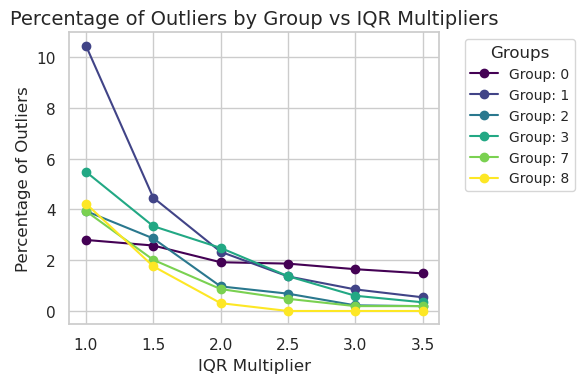

In [276]:
iqrs = [1,1.5,2,2.5,3,3.5]
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_scaled_union_runtimeMinutes.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "runtimeMinutes", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=True)

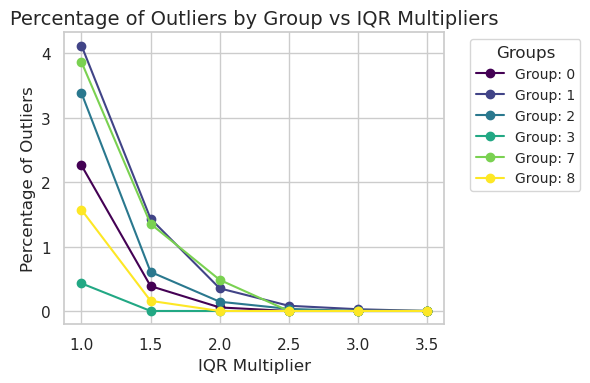

In [277]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_totalCredits.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "totalCredits", "titleType", iqrs, output_file, show_plot=True)

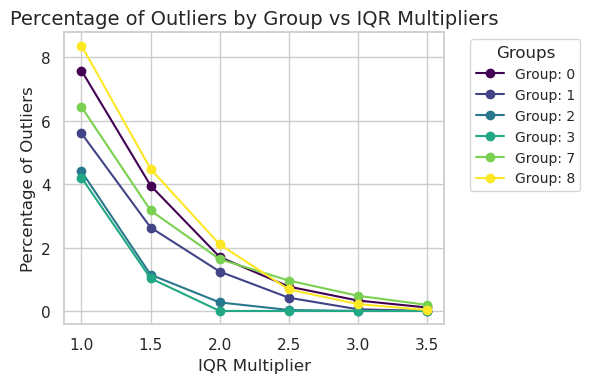

In [278]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_numVotes.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "numVotes", "titleType", iqrs, output_file, show_plot=True)

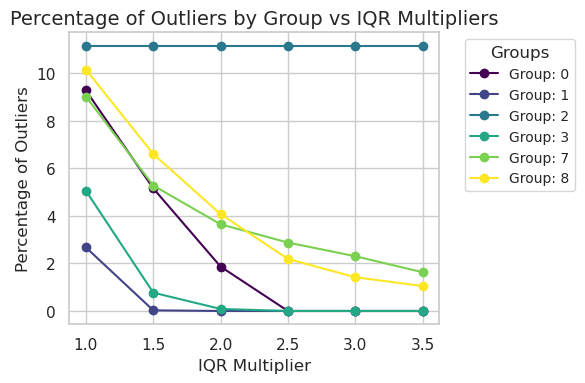

In [279]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_numRegions.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "numRegions", "titleType", iqrs, output_file, show_plot=True, detect_lower_outliers=False)

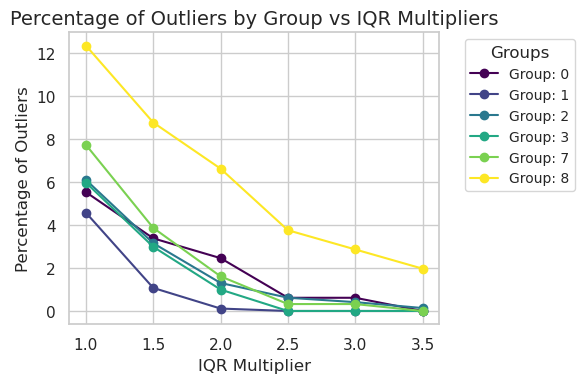

In [280]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_criticReviewsTotal.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "criticReviewsTotal", "titleType", iqrs, output_file, show_plot=True)

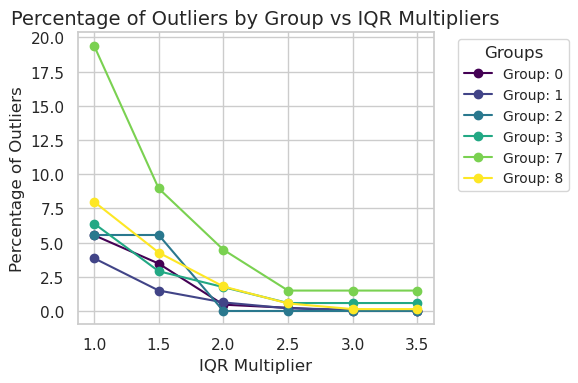

In [281]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_nominations.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "totalRecognitions", "titleType", iqrs, output_file, show_plot=True)

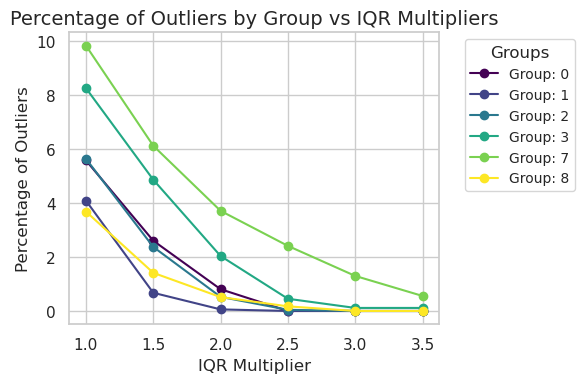

In [282]:
output_file = "data/output/02_data_understanding/outliers_analysis/outliers_union_totalMedia.csv"
calculate_and_store_outliers_union(scaled_train, scaled_test, "totalMedia", "titleType", iqrs, output_file, show_plot=True)

In [283]:
# print percentage of 1 in columns named as the content of encoding_lists/genres.txt

def print_percentage_of_1(data, columns):
    """
    Print the percentage of 1 values in the specified columns of a DataFrame.

    Args:
        data (pd.DataFrame): The input DataFrame.
        columns (list): List of column names to analyze.

    Returns:
        None
    """
    for column in columns:
        if column in data.columns:
            num_ones = data[column].sum()
            total_elements = len(data[column])
            percentage = num_ones / total_elements * 100
            print(f"Percentage of 1 values in column '{column}': {percentage:.2f}%")
        else:
            print(f"Column '{column}' not found in the DataFrame.")

# Load the list of genres
with open("encoding_lists/genres.txt", "r") as file:
    genres = file.read().splitlines()

# Print the percentage of 1 values for each genre
print_percentage_of_1(data_train, genres)

Percentage of 1 values in column 'Action': 11.24%
Percentage of 1 values in column 'Adult': 2.66%
Percentage of 1 values in column 'Adventure': 9.29%
Percentage of 1 values in column 'Animation': 9.17%
Percentage of 1 values in column 'Biography': 1.72%
Percentage of 1 values in column 'Comedy': 29.42%
Percentage of 1 values in column 'Crime': 10.84%
Percentage of 1 values in column 'Documentary': 11.23%
Percentage of 1 values in column 'Drama': 36.86%
Percentage of 1 values in column 'Family': 7.43%
Percentage of 1 values in column 'Fantasy': 3.70%
Percentage of 1 values in column 'Film-Noir': 0.17%
Percentage of 1 values in column 'Game-Show': 1.55%
Percentage of 1 values in column 'History': 2.17%
Percentage of 1 values in column 'Horror': 4.24%
Percentage of 1 values in column 'Music': 3.19%
Percentage of 1 values in column 'Musical': 1.42%
Percentage of 1 values in column 'Mystery': 3.95%
Percentage of 1 values in column 'News': 1.00%
Percentage of 1 values in column 'Reality-TV':

# Outliers eliminations

In [284]:
import pandas as pd

def add_outlier_column(data_train, data_test, data_normalized_train, data_normalized_test):
    """
    Aggiunge una colonna 'outlier' con valori iniziali impostati a 0 nei quattro dataset.

    Args:
        data_train (pd.DataFrame): Dataset di addestramento originale.
        data_test (pd.DataFrame): Dataset di test originale.
        data_normalized_train (pd.DataFrame): Dataset di addestramento normalizzato.
        data_normalized_test (pd.DataFrame): Dataset di test normalizzato.

    Returns:
        tuple: Quattro DataFrame con la nuova colonna 'outlier'.
    """
    data_train['outlier'] = 0
    data_test['outlier'] = 0
    data_normalized_train['outlier'] = 0
    data_normalized_test['outlier'] = 0
    return data_train, data_test, data_normalized_train, data_normalized_test


def mark_outliers_iqr_by_group(data_train, data_test, data_normalized_train, data_normalized_test, column, group_column, iqr_multiplier=1.5, remove_both_sides=True):
    """
    Identifica gli outlier utilizzando l'IQR specificato per ciascun gruppo definito da group_column
    e imposta a 1 la colonna 'outlier' nei quattro dataset.

    Args:
        data_train (pd.DataFrame): Dataset di addestramento originale con colonna 'outlier'.
        data_test (pd.DataFrame): Dataset di test originale con colonna 'outlier'.
        data_normalized_train (pd.DataFrame): Dataset di addestramento normalizzato con colonna 'outlier'.
        data_normalized_test (pd.DataFrame): Dataset di test normalizzato con colonna 'outlier'.
        column (str): Colonna su cui calcolare gli outlier.
        group_column (str): Colonna per effettuare il group_by.
        iqr_multiplier (float): Moltiplicatore per definire i limiti degli outlier.
        remove_both_sides (bool): Se True, rileva outlier superiori e inferiori; se False, solo superiori.

    Returns:
        None: Modifica i dataset in-place.
    """
    # Unisce i dati normalizzati per un calcolo combinato per ciascun gruppo
    combined_data = pd.concat([
        data_normalized_train[[group_column, column]],
        data_normalized_test[[group_column, column]]
    ], ignore_index=True)

    # Identifica i gruppi
    groups = combined_data[group_column].unique()

    # Itera sui gruppi
    for group in groups:
        # Filtra i dati del gruppo
        group_data = combined_data[combined_data[group_column] == group]

        # Escludi temporaneamente valori nulli e zeri per il calcolo dell'IQR
        if remove_both_sides:
            non_null_data = group_data[column][group_data[column].notnull()]
        else:
            non_null_data = group_data[column][group_data[column].notnull() & (group_data[column] != 0)]

        if non_null_data.empty:
            continue

        q1 = non_null_data.quantile(0.25)
        q3 = non_null_data.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - iqr_multiplier * iqr if remove_both_sides else float('-inf')
        upper_bound = q3 + iqr_multiplier * iqr

        # Funzione helper per identificare gli outlier
        def is_outlier(value):
            return value < lower_bound or value > upper_bound

        # Identifica gli outlier per il gruppo nei dataset normalizzati
        normalized_train_outliers = data_normalized_train[
            (data_normalized_train[group_column] == group)
        ][column].apply(is_outlier)

        normalized_test_outliers = data_normalized_test[
            (data_normalized_test[group_column] == group)
        ][column].apply(is_outlier)

        # Aggiorna la colonna 'outlier' nei dataset normalizzati
        data_normalized_train.loc[data_normalized_train[group_column] == group, 'outlier'] |= normalized_train_outliers.astype(int)
        data_normalized_test.loc[data_normalized_test[group_column] == group, 'outlier'] |= normalized_test_outliers.astype(int)

        # Conta gli outlier per gruppo
        group_train_outliers = normalized_train_outliers.sum()
        group_test_outliers = normalized_test_outliers.sum()

        print(f"Gruppo '{group}': {group_train_outliers} outlier trovati nel dataset di addestramento normalizzato, {group_test_outliers} outlier trovati nel dataset di test normalizzato.")

    # Propaga gli outlier ai dataset originali
    data_train['outlier'] = data_train['outlier'] | data_normalized_train['outlier']
    data_test['outlier'] = data_test['outlier'] | data_normalized_test['outlier']

    # Conta gli outlier
    train_outliers = data_train['outlier'].sum()
    test_outliers = data_test['outlier'].sum()

    # Stampa i risultati
    print(f"Outlier trovati nel dataset di addestramento originale: {train_outliers}")
    print(f"Outlier trovati nel dataset di test originale: {test_outliers}")



def remove_outliers(data_train, data_test, data_normalized_train, data_normalized_test):
    """
    Elimina le righe marcate come outlier (colonna 'outlier' = 1) dai quattro dataset.

    Args:
        data_train (pd.DataFrame): Dataset di addestramento con colonna 'outlier'.
        data_test (pd.DataFrame): Dataset di test con colonna 'outlier'.
        data_normalized_train (pd.DataFrame): Dataset di addestramento normalizzato con colonna 'outlier'.
        data_normalized_test (pd.DataFrame): Dataset di test normalizzato con colonna 'outlier'.

    Returns:
        tuple: Quattro DataFrame senza outlier.
    """
    data_train_cleaned = data_train[data_train['outlier'] == 0].drop(columns=['outlier'])
    data_test_cleaned = data_test[data_test['outlier'] == 0].drop(columns=['outlier'])
    data_normalized_train_cleaned = data_normalized_train[data_normalized_train['outlier'] == 0].drop(columns=['outlier'])
    data_normalized_test_cleaned = data_normalized_test[data_normalized_test['outlier'] == 0].drop(columns=['outlier'])

    # Calcola il numero di righe eliminate e le percentuali
    train_outliers = len(data_train) - len(data_train_cleaned)
    test_outliers = len(data_test) - len(data_test_cleaned)
    normalized_train_outliers = len(data_normalized_train) - len(data_normalized_train_cleaned)
    normalized_test_outliers = len(data_normalized_test) - len(data_normalized_test_cleaned)

    train_percentage = (train_outliers / len(data_train)) * 100 if len(data_train) > 0 else 0
    test_percentage = (test_outliers / len(data_test)) * 100 if len(data_test) > 0 else 0
    normalized_train_percentage = (normalized_train_outliers / len(data_normalized_train)) * 100 if len(data_normalized_train) > 0 else 0
    normalized_test_percentage = (normalized_test_outliers / len(data_normalized_test)) * 100 if len(data_normalized_test) > 0 else 0

    # Stampa informazioni sulle righe eliminate
    print("Righe eliminate:")
    print(f"Dataset di addestramento: {train_outliers} ({train_percentage:.2f}%)")
    print(f"Dataset di test: {test_outliers} ({test_percentage:.2f}%)")
    print(f"Dataset di addestramento normalizzato: {normalized_train_outliers} ({normalized_train_percentage:.2f}%)")
    print(f"Dataset di test normalizzato: {normalized_test_outliers} ({normalized_test_percentage:.2f}%)")

    return data_train_cleaned, data_test_cleaned, data_normalized_train_cleaned, data_normalized_test_cleaned



In [285]:
add_outlier_column(data_train, data_test, scaled_train, scaled_test)

_iqr = 1.5

In [286]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "runtimeMinutes","titleType", iqr_multiplier=_iqr, remove_both_sides=True)

Gruppo '2': 122 outlier trovati nel dataset di addestramento normalizzato, 58 outlier trovati nel dataset di test normalizzato.
Gruppo '1': 253 outlier trovati nel dataset di addestramento normalizzato, 78 outlier trovati nel dataset di test normalizzato.
Gruppo '0': 37 outlier trovati nel dataset di addestramento normalizzato, 10 outlier trovati nel dataset di test normalizzato.
Gruppo '7': 17 outlier trovati nel dataset di addestramento normalizzato, 4 outlier trovati nel dataset di test normalizzato.
Gruppo '8': 40 outlier trovati nel dataset di addestramento normalizzato, 17 outlier trovati nel dataset di test normalizzato.
Gruppo '3': 28 outlier trovati nel dataset di addestramento normalizzato, 11 outlier trovati nel dataset di test normalizzato.
Outlier trovati nel dataset di addestramento originale: 497
Outlier trovati nel dataset di test originale: 178


In [287]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "numRegions","titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo '2': 528 outlier trovati nel dataset di addestramento normalizzato, 175 outlier trovati nel dataset di test normalizzato.
Gruppo '1': 1 outlier trovati nel dataset di addestramento normalizzato, 1 outlier trovati nel dataset di test normalizzato.
Gruppo '0': 74 outlier trovati nel dataset di addestramento normalizzato, 20 outlier trovati nel dataset di test normalizzato.
Gruppo '7': 35 outlier trovati nel dataset di addestramento normalizzato, 20 outlier trovati nel dataset di test normalizzato.
Gruppo '8': 159 outlier trovati nel dataset di addestramento normalizzato, 55 outlier trovati nel dataset di test normalizzato.
Gruppo '3': 4 outlier trovati nel dataset di addestramento normalizzato, 5 outlier trovati nel dataset di test normalizzato.
Outlier trovati nel dataset di addestramento originale: 1281
Outlier trovati nel dataset di test originale: 447


In [288]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "totalCredits", "titleType", iqr_multiplier=_iqr, remove_both_sides=False)


Gruppo '2': 33 outlier trovati nel dataset di addestramento normalizzato, 5 outlier trovati nel dataset di test normalizzato.
Gruppo '1': 79 outlier trovati nel dataset di addestramento normalizzato, 27 outlier trovati nel dataset di test normalizzato.
Gruppo '0': 7 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Gruppo '7': 11 outlier trovati nel dataset di addestramento normalizzato, 3 outlier trovati nel dataset di test normalizzato.
Gruppo '8': 4 outlier trovati nel dataset di addestramento normalizzato, 1 outlier trovati nel dataset di test normalizzato.
Gruppo '3': 0 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Outlier trovati nel dataset di addestramento originale: 1400
Outlier trovati nel dataset di test originale: 475


In [289]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "numVotes", "titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo '2': 58 outlier trovati nel dataset di addestramento normalizzato, 14 outlier trovati nel dataset di test normalizzato.
Gruppo '1': 144 outlier trovati nel dataset di addestramento normalizzato, 51 outlier trovati nel dataset di test normalizzato.
Gruppo '0': 59 outlier trovati nel dataset di addestramento normalizzato, 13 outlier trovati nel dataset di test normalizzato.
Gruppo '7': 22 outlier trovati nel dataset di addestramento normalizzato, 11 outlier trovati nel dataset di test normalizzato.
Gruppo '8': 113 outlier trovati nel dataset di addestramento normalizzato, 32 outlier trovati nel dataset di test normalizzato.
Gruppo '3': 9 outlier trovati nel dataset di addestramento normalizzato, 3 outlier trovati nel dataset di test normalizzato.
Outlier trovati nel dataset di addestramento originale: 1586
Outlier trovati nel dataset di test originale: 527


In [290]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "criticReviewsTotal","titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo '2': 39 outlier trovati nel dataset di addestramento normalizzato, 7 outlier trovati nel dataset di test normalizzato.
Gruppo '1': 27 outlier trovati nel dataset di addestramento normalizzato, 11 outlier trovati nel dataset di test normalizzato.
Gruppo '0': 8 outlier trovati nel dataset di addestramento normalizzato, 3 outlier trovati nel dataset di test normalizzato.
Gruppo '7': 8 outlier trovati nel dataset di addestramento normalizzato, 4 outlier trovati nel dataset di test normalizzato.
Gruppo '8': 40 outlier trovati nel dataset di addestramento normalizzato, 9 outlier trovati nel dataset di test normalizzato.
Gruppo '3': 5 outlier trovati nel dataset di addestramento normalizzato, 4 outlier trovati nel dataset di test normalizzato.
Outlier trovati nel dataset di addestramento originale: 1616
Outlier trovati nel dataset di test originale: 535


In [291]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "totalRecognitions", "titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo '2': 1 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Gruppo '1': 26 outlier trovati nel dataset di addestramento normalizzato, 5 outlier trovati nel dataset di test normalizzato.
Gruppo '0': 13 outlier trovati nel dataset di addestramento normalizzato, 2 outlier trovati nel dataset di test normalizzato.
Gruppo '7': 4 outlier trovati nel dataset di addestramento normalizzato, 2 outlier trovati nel dataset di test normalizzato.
Gruppo '8': 21 outlier trovati nel dataset di addestramento normalizzato, 10 outlier trovati nel dataset di test normalizzato.
Gruppo '3': 4 outlier trovati nel dataset di addestramento normalizzato, 1 outlier trovati nel dataset di test normalizzato.
Outlier trovati nel dataset di addestramento originale: 1645
Outlier trovati nel dataset di test originale: 543


In [292]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "totalMedia", "titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo '2': 75 outlier trovati nel dataset di addestramento normalizzato, 34 outlier trovati nel dataset di test normalizzato.
Gruppo '1': 35 outlier trovati nel dataset di addestramento normalizzato, 11 outlier trovati nel dataset di test normalizzato.
Gruppo '0': 35 outlier trovati nel dataset di addestramento normalizzato, 7 outlier trovati nel dataset di test normalizzato.
Gruppo '7': 24 outlier trovati nel dataset di addestramento normalizzato, 9 outlier trovati nel dataset di test normalizzato.
Gruppo '8': 22 outlier trovati nel dataset di addestramento normalizzato, 11 outlier trovati nel dataset di test normalizzato.
Gruppo '3': 33 outlier trovati nel dataset di addestramento normalizzato, 10 outlier trovati nel dataset di test normalizzato.
Outlier trovati nel dataset di addestramento originale: 1771
Outlier trovati nel dataset di test originale: 587


In [293]:
mark_outliers_iqr_by_group(data_train, data_test, scaled_train, scaled_test, "userReviewsTotal", "titleType", iqr_multiplier=_iqr, remove_both_sides=False)

Gruppo '2': 63 outlier trovati nel dataset di addestramento normalizzato, 12 outlier trovati nel dataset di test normalizzato.
Gruppo '1': 52 outlier trovati nel dataset di addestramento normalizzato, 25 outlier trovati nel dataset di test normalizzato.
Gruppo '0': 21 outlier trovati nel dataset di addestramento normalizzato, 4 outlier trovati nel dataset di test normalizzato.
Gruppo '7': 28 outlier trovati nel dataset di addestramento normalizzato, 16 outlier trovati nel dataset di test normalizzato.
Gruppo '8': 7 outlier trovati nel dataset di addestramento normalizzato, 4 outlier trovati nel dataset di test normalizzato.
Gruppo '3': 2 outlier trovati nel dataset di addestramento normalizzato, 0 outlier trovati nel dataset di test normalizzato.
Outlier trovati nel dataset di addestramento originale: 1799
Outlier trovati nel dataset di test originale: 597


In [294]:
data_train, data_test, scaled_train, scaled_test = remove_outliers(data_train, data_test, scaled_train, scaled_test)

Righe eliminate:
Dataset di addestramento: 1799 (11.43%)
Dataset di test: 597 (11.40%)
Dataset di addestramento normalizzato: 1799 (11.43%)
Dataset di test normalizzato: 597 (11.40%)


In [295]:
# print number of rows with runtimeMinutes na
print(data_train['runtimeMinutes'].isna().sum())

4031


# Fill missing values with median

In [296]:
def fill_missing_values_with_median(data, column_to_fill, group_by_column):
    """
    Fill missing values in a specified column with the median value of the column grouped by another column.

    Args:
        data (pd.DataFrame): The input dataset containing the column to fill and the group-by column.
        column_to_fill (str): The column in which to fill missing values.
        group_by_column (str): The column to group by when calculating the median.

    Returns:
        pd.DataFrame: A DataFrame with missing values in the specified column filled.
    """
    # Ensure the columns exist in the dataset
    if column_to_fill not in data.columns:
        raise ValueError(f"Column '{column_to_fill}' not found in the dataset.")
    if group_by_column not in data.columns:
        raise ValueError(f"Group-by column '{group_by_column}' not found in the dataset.")

    # Work on a copy of the data to avoid unintended side-effects
    data = data.copy()

    # Replace '\N' with NaN for proper handling of missing values
    data.loc[:, column_to_fill] = pd.to_numeric(data[column_to_fill], errors='coerce')  # Ensure numeric type
    data.loc[:, group_by_column] = data[group_by_column].astype(str)  # Ensure the group-by column is a string

    # Fill missing values with the median of the group
    data.loc[:, column_to_fill] = data.groupby(group_by_column)[column_to_fill].transform(
        lambda x: x.fillna(x.median())
    )

    return data


In [297]:
data_train = fill_missing_values_with_median(data_train, "runtimeMinutes", "titleType")
data_test = fill_missing_values_with_median(data_test, "runtimeMinutes", "titleType")
scaled_train = fill_missing_values_with_median(scaled_train, "runtimeMinutes", "titleType")
scaled_test = fill_missing_values_with_median(scaled_test, "runtimeMinutes", "titleType")

/tmp/ipykernel_13276/2422934563.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['2' '1' '0' ... '1' '1' '8']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, group_by_column] = data[group_by_column].astype(str)  # Ensure the group-by column is a string
/tmp/ipykernel_13276/2422934563.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['7' '1' '2' ... '2' '1' '0']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, group_by_column] = data[group_by_column].astype(str)  # Ensure the group-by column is a string
/tmp/ipykernel_13276/2422934563.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['2' '1' '0' ... '1' '1' '8']' has dtype incompatible with int64, please ex

# Correlation

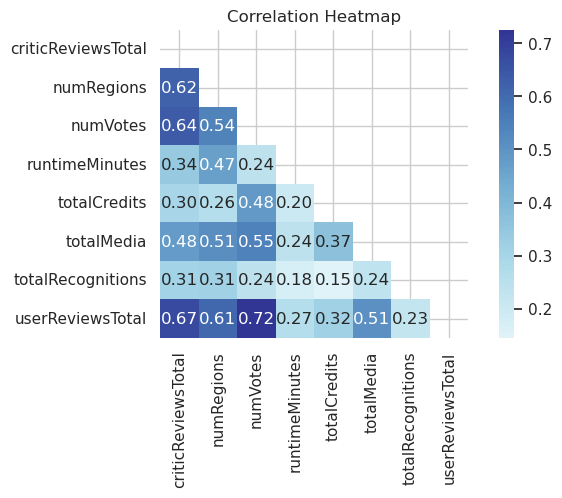

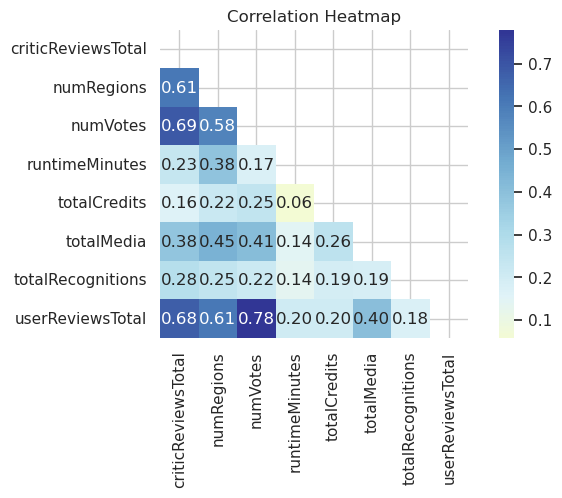

(            Variable 1         Variable 2  Correlation
 28      runtimeMinutes       totalCredits     0.058077
 30      runtimeMinutes  totalRecognitions     0.137946
 43          totalMedia     runtimeMinutes     0.142984
 4   criticReviewsTotal       totalCredits     0.163491
 19            numVotes     runtimeMinutes     0.173714
 55   totalRecognitions   userReviewsTotal     0.175445
 53   totalRecognitions         totalMedia     0.187979
 38        totalCredits  totalRecognitions     0.192919
 60    userReviewsTotal       totalCredits     0.202174
 31      runtimeMinutes   userReviewsTotal     0.203344,
             Variable 1          Variable 2  Correlation
 11          numRegions      runtimeMinutes     0.384989
 47          totalMedia    userReviewsTotal     0.401935
 21            numVotes          totalMedia     0.408396
 41          totalMedia          numRegions     0.448686
 10          numRegions            numVotes     0.580570
 1   criticReviewsTotal          numRegio

In [298]:
subset_columns = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

analyze_correlation(scaled_train, subset_columns, show_plot=True)
analyze_correlation(data_train, subset_columns, show_plot=True)

In [299]:
# Lista di tutti i paesi dal file countryOfOrigin.txt
with open('encoding_lists/countryOfOrigin.txt', 'r') as f:
    all_countries = [line.strip() for line in f]

# Aggiungere colonne per i paesi mancanti in train e test
# Per ogni paese assente, aggiungere una colonna con valore 0
for country in all_countries:
    if country not in data_train.columns:
        data_train[country] = 0
    if country not in data_test.columns:
        data_test[country] = 0

# Ordinare solo le colonne corrispondenti ai paesi
data_train = data_train[[col for col in data_train.columns if col not in all_countries] + 
                    [col for col in all_countries if col in data_train.columns]]
data_test = data_test[[col for col in data_test.columns if col not in all_countries] + 
                   [col for col in all_countries if col in data_test.columns]]

# now for the scaled datasets
for country in all_countries:
    if country not in scaled_train.columns:
        scaled_train[country] = 0
    if country not in scaled_test.columns:
        scaled_test[country] = 0

# Ordinare solo le colonne corrispondenti ai paesi
scaled_train = scaled_train[[col for col in scaled_train.columns if col not in all_countries] + 
                    [col for col in all_countries if col in scaled_train.columns]]
scaled_test = scaled_test[[col for col in scaled_test.columns if col not in all_countries] + 
                   [col for col in all_countries if col in scaled_test.columns]]

In [300]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

# store the 4 datasets
store_dataset(data_train, 'data/output/02_data_understanding/clean_data_train')
store_dataset(data_test, 'data/output/02_data_understanding/clean_data_test')
store_dataset(scaled_train, 'data/output/02_data_understanding/clean_normalized_data_train')
store_dataset(scaled_test, 'data/output/02_data_understanding/clean_normalized_data_test')

Dataset successfully stored as data/output/02_data_understanding/clean_data_train.csv
Dataset successfully stored as data/output/02_data_understanding/clean_data_test.csv
Dataset successfully stored as data/output/02_data_understanding/clean_normalized_data_train.csv
Dataset successfully stored as data/output/02_data_understanding/clean_normalized_data_test.csv


'data/output/02_data_understanding/clean_normalized_data_test.csv'

In [303]:
subset_columns = [
    "criticReviewsTotal",
    "numRegions",
    "numVotes",
    "rating",
    "runtimeMinutes",
    "totalCredits",
    "totalMedia",
    "totalRecognitions",
    "userReviewsTotal"
]

# print information on the datasets only for the columns in subset_columns
print(scaled_train[subset_columns].describe())

       criticReviewsTotal    numRegions      numVotes        rating  \
count        13943.000000  13943.000000  13943.000000  13943.000000   
mean             0.404557      1.083674      3.934648      7.115757   
std              0.781856      0.632520      1.524691      1.397509   
min              0.000000      0.693147      1.791759      1.000000   
25%              0.000000      0.693147      2.772589      6.000000   
50%              0.000000      0.693147      3.555348      7.000000   
75%              0.693147      1.386294      4.844187      8.000000   
max              4.812184      3.828641      9.609586     10.000000   

       runtimeMinutes  totalCredits    totalMedia  totalRecognitions  \
count    13943.000000  13943.000000  13943.000000       13943.000000   
mean         0.923056      3.454503      1.224308           0.203591   
std          0.566373      1.051996      1.066979           0.538389   
min          0.000000      0.000000      0.000000           0.000000   


In [305]:
print(scaled_test[subset_columns].describe())

       criticReviewsTotal   numRegions     numVotes       rating  \
count         4641.000000  4641.000000  4641.000000  4641.000000   
mean             0.418767     1.096854     3.954223     7.123249   
std              0.803627     0.643263     1.536490     1.393141   
min              0.000000     0.693147     1.791759     1.000000   
25%              0.000000     0.693147     2.708050     6.000000   
50%              0.000000     0.693147     3.610918     7.000000   
75%              0.693147     1.386294     4.875197     8.000000   
max              5.147494     3.583519     9.607437    10.000000   

       runtimeMinutes  totalCredits   totalMedia  totalRecognitions  \
count     4641.000000   4641.000000  4641.000000        4641.000000   
mean         0.943863      3.482910     1.250560           0.197774   
std          0.565822      1.031358     1.084817           0.535061   
min          0.016667      0.000000     0.000000           0.000000   
25%          0.500000      2.833

In [306]:
data_train.describe()

,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,totalRecognitions,NumberOfCountryoforigin,...,VC,VE,VN,XKV,XWG,XYU,YUCS,ZA,ZM,ZW
count,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,...,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000,13943.000000
mean,7.115757,1990.937029,55.383346,246.218891,51.289249,1.672094,2.916661,2.922972,0.596930,1.087571,...,0.000072,0.001291,0.000789,0.000072,0.014990,0.003658,0.000359,0.002725,0.000072,0.000072
std,1.397509,26.489942,33.982376,884.273132,68.327586,6.534696,4.325575,10.489713,2.365819,0.374759,...,0.008469,0.035908,0.028078,0.008469,0.121515,0.060371,0.018934,0.052136,0.008469,0.008469
min,1.000000,1878.000000,0.000000,5.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1976.000000,30.000000,15.000000,16.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,1996.000000,50.000000,34.000000,34.000000,0.000000,1.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,2012.000000,90.000000,126.000000,62.000000,1.000000,3.000000,2.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,2024.000000,176.000000,14906.000000,1885.000000,122.000000,45.000000,296.000000,49.000000,8.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
